# Inverse design quickstart

This notebook will get users up and running with a very simple inverse design optimization with `tidy3d`. Inverse design uses the "adjoint method" to compute gradients of a figure of merit with respect to design parameters using only 2 simulations, no matter how many design parameters are present. This gradient is then used to do high-dimensional gradient-based optimization of the system.

The setup we'll demonstrate here involves a point dipole source and a point field monitor on either side of a dielectric box. We use gradient-based optimization to maximize the intensity enhancement at the measurement spot with respect to the box size in all 3 dimensions.

<img src="img/Adjoint_Quickstart.png" width="300" alt="Schematic of the design problem.">

For more detailed notebooks, see these

* [Tidy3D Autograd Tutorial](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd1Intro/).

* [Topology Optimization](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/).

* [Shape Optimization](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd5BoundaryGradients/).

* [Grating Coupler Inverse Design](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd6GratingCoupler/).


In [1]:
# To install optax that provides the optimizer, uncomment the lines below.
# !pip install optax

In [2]:
import tidy3d as td
from tidy3d.web import run
import matplotlib.pylab as plt

import autograd as ag
import autograd.numpy as anp
import optax

## Setup

First, we set up some basic parameters and "static" components of our simulation.

In [3]:
# wavelength and frequency
wavelength = 1.55
freq0 = td.C_0 / wavelength

# permittivity of box
eps_box = 2

# size of sim in x,y,z
L = 10 * wavelength

# spacing between source, monitor, and PML / box
buffer = 1.0 * wavelength

Create a [PointDipole](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PointDipole.html) source.

In [4]:
# create a dipole source on the left side of the simulation
source = td.PointDipole(
    center=(-L / 2 + buffer, 0, 0),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10.0),
    polarization="Ez",
)

Create a point [FieldMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldMonitor.html).

In [5]:
# create a monitor on the right side of the simulation to measure field intensity
monitor = td.FieldMonitor(
    center=(+L / 2 - buffer, 0, 0),
    size=(0.0, 0.0, 0.0),
    freqs=[freq0],
    name="point",
)

## Define Objective Function

Now we construct our objective function. Our objective function measures the intensity at the measurement point as a function of the box size.

In [6]:
def make_sim(size_box: float) -> td.Simulation:
    """Create the simulation given a box size."""
    # create the box
    box = td.Structure(
        geometry=td.Box(center=(0, 0, 0), size=(size_box, size_box, size_box)),
        medium=td.Medium(permittivity=eps_box),
    )

    # create the simulation
    sim = td.Simulation(
        size=(L, L, L),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=20),
        structures=[box],
        sources=[source],
        monitors=[monitor],
        run_time=5e-13,
    )
    return sim


def objective_fn(size_box: float) -> float:
    """Calculate the intensity at the monitor position given a box size."""

    # make the sim using the box size
    sim = make_sim(size_box)

    # run sim through tidy3d web API
    sim_data = run(sim, task_name="adjoint_quickstart", verbose=False)

    # evaluate the intensity at the measurement position
    intensity = anp.sum(sim_data.get_intensity(monitor.name).values)

    return intensity

To visualize the simulation setup, we create an initial simulation with a box of size 2.5 μm and visualize it.

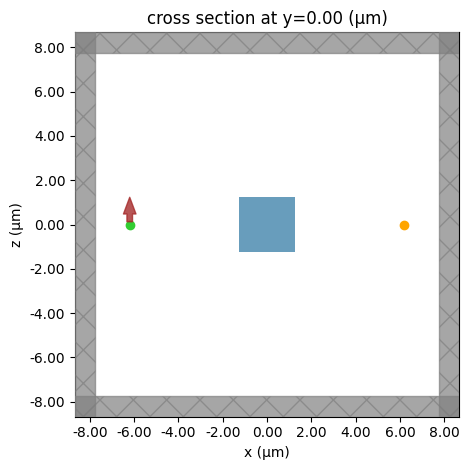

In [7]:
size_box = 2.5  # initial box size

# create a simulation and visualize the setup
sim_0 = make_sim(size_box)
sim_0.plot(y=0)
plt.show()

## Optimization Loop

Next, we use `autograd` to construct a function that returns the gradient of our objective function and use this to run our gradient-based optimization in a for loop.

In [8]:
# use autograd to get a function that returns the objective function and its gradient
val_and_grad_fn = ag.value_and_grad(objective_fn)

In [9]:
# hyperparameters
num_steps = 8  # number of iterations
learning_rate = 0.2

# initialize adam optimizer with starting parameter
optimizer = optax.adam(learning_rate=learning_rate)
opt_state = optimizer.init(size_box)

# store history
objective_history = []  # list to store the history of the objective function
param_history = [size_box]  # list to store the history of the box size

for i in range(num_steps):
    print(f"step = {i + 1}\n\tsize_box = {size_box:.2f}", end="")

    # compute gradient and current objective function value
    value, gradient = val_and_grad_fn(size_box)
    print(f"\n\tintensity = {value:.2e}")

    # compute and apply updates to the optimizer based on gradient (-1 sign to maximize objective_fn)
    updates, opt_state = optimizer.update(-gradient, opt_state, size_box)
    size_box = float(optax.apply_updates(size_box, updates))

    # save history
    objective_history.append(value)
    param_history.append(size_box)

# add the objective function of the last iteration to the history list
objective_history.append(val_and_grad_fn(size_box)[0])

step = 1
	size_box = 2.50
	intensity = 7.45e+02
step = 2
	size_box = 2.70
	intensity = 9.55e+02
step = 3
	size_box = 2.90
	intensity = 1.10e+03
step = 4
	size_box = 3.10
	intensity = 1.24e+03
step = 5
	size_box = 3.30
	intensity = 1.54e+03
step = 6
	size_box = 3.50
	intensity = 1.75e+03
step = 7
	size_box = 3.69
	intensity = 1.96e+03
step = 8
	size_box = 3.89
	intensity = 2.17e+03


## Analysis
After the optimization is done, we can plot the intensity as a function of the iteration number. As expected, the intensity is increasing as the optimization progresses.

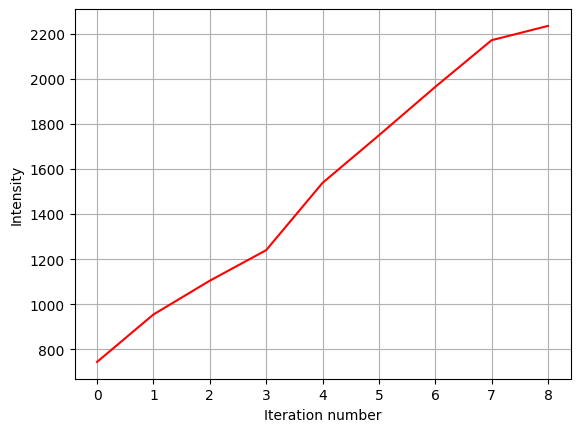

In [10]:
# plot the objective function vs iteration
plt.plot(objective_history, c="red")
plt.xlabel("Iteration number")
plt.ylabel("Intensity")
plt.grid()
plt.show()

To plot the field pattern, we create a 2D [FieldMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldMonitor.html) and add it to the final simulation by using the [update_copy](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.components.base.Tidy3dBaseModel.html#tidy3d.components.base.Tidy3dBaseModel.updated_copy) method. Then we run this simulation.

In [11]:
# construct simulation with the final box size
sim_final = make_sim(size_box=param_history[-1])

# add a field monitor for plotting
field_monitor = td.FieldMonitor(
    center=(+L / 2 - buffer, 0, 0),
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name="fields",
)
sim_final = sim_final.updated_copy(monitors=[field_monitor])

# run the final simulation
data_final = run(sim_final, task_name="quickstart_final")

21:55:37 Eastern Daylight Time Created task 'quickstart_final' with task_id     
                               'fdve-32c7caf5-71ef-4932-bc45-a778c9d49872' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=15824;https://tidy3d.simulation.cloud/workbench?taskId=fdve-32c7caf5-71ef-4932-bc45-a778c9d49872\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=889496;https://tidy3d.simulation.cloud/workbench?taskId=fdve-32c7caf5-71ef-4932-bc45-a778c9d49872\taskId]8;;\
                               ]8;id=15824;https://tidy3d.simulation.cloud/workbench?taskId=fdve-32c7caf5-71ef-4932-bc45-a778c9d49872\=]8;;\]8;id=996128;https://tidy3d.simulation.cloud/workbench?taskId=fdve-32c7caf5-71ef-4932-bc45-a778c9d49872\fdve]8;;\]8;id=15824;https://tidy3d.simulation.cloud/workbench?taskId=fdve-32c7caf5-71ef-4932-bc45-a778c9d49872\-32c7caf5-71ef-4932-bc45-a778c9d49872']8;;\.

                               Task folder: ]8;id=590404;https://tidy3d.simulation.cloud/folders/639eb096-a602-4b56-a502-cac1f18f9557\'default']8;;\.

Output()

21:55:38 Eastern Daylight Time Maximum FlexCredit cost: 0.025. Minimum cost     
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

                               status = success

Output()

21:55:40 Eastern Daylight Time loading simulation from simulation_data.hdf5

Finally, the field distribution is plotted. We denote the source position with a green dot and the measurement position with an orange dot. The orange dot is near a field hotspot as a result of the optimization.

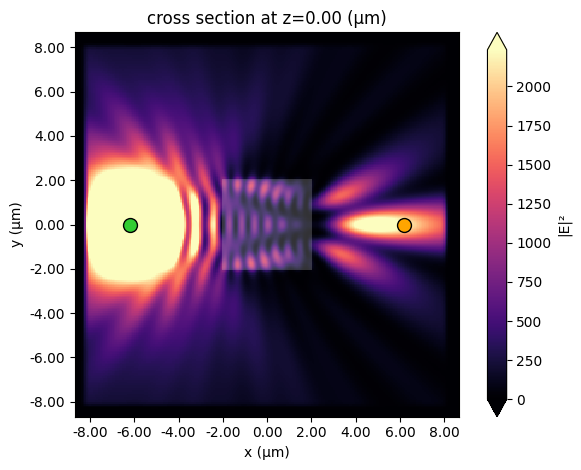

In [12]:
# plot intensity distribution
ax = data_final.plot_field(
    field_monitor_name="fields", field_name="E", val="abs^2", vmax=objective_history[-1]
)

ax.plot(source.center[0], 0, marker="o", mfc="limegreen", mec="black", ms=10)
ax.plot(monitor.center[0], 0, marker="o", mfc="orange", mec="black", ms=10)
plt.show()